In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

import requests
from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

torch.Size([1, 28, 28])


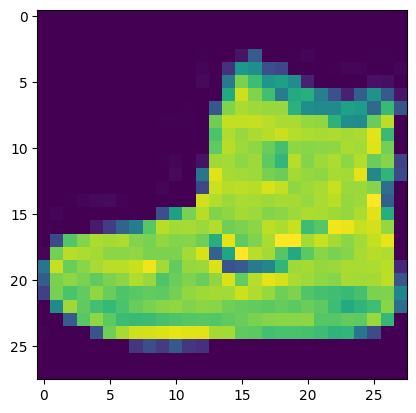

In [3]:
image, label = train_data[0]
plt.imshow(image.squeeze())
print(image.shape)

In [4]:
print(len(train_data.data), len(train_data.targets))
print(len(test_data.data), len(test_data.targets))

60000 60000
10000 10000


In [5]:
class_names = train_data.classes
class_names_set = set(class_names)
print(class_names_set)

{'T-shirt/top', 'Bag', 'Coat', 'Sandal', 'Pullover', 'Ankle boot', 'Trouser', 'Sneaker', 'Dress', 'Shirt'}


Image shape: torch.Size([1, 28, 28])


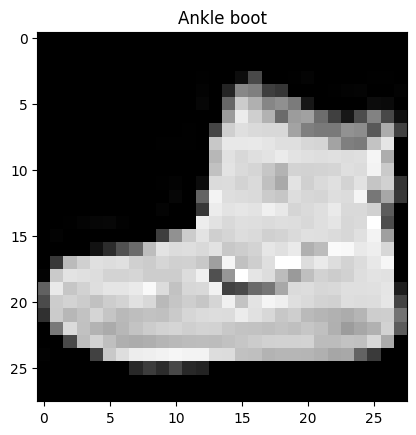

In [ ]:
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze(), cmap="grey") # image shape is [1, 28, 28] (colour channels, height, width)
plt.title(class_names[label])

plt.show()

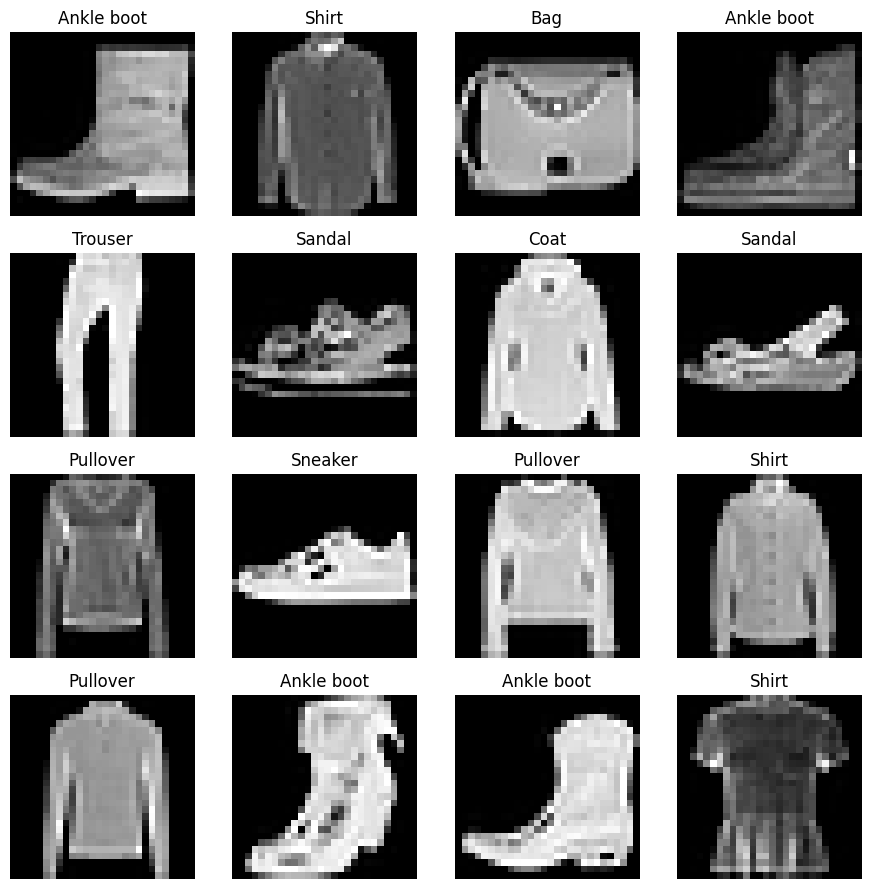

In [ ]:
torch.manual_seed(42)
fig = plt.figure(figsize=(11, 11))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

In [11]:
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [12]:
print(len(next(iter(train_dataloader))))
print("image: ", next(iter(train_dataloader))[0].shape, "; label: ", next(iter(train_dataloader))[1].shape)

2
image:  torch.Size([32, 1, 28, 28]) ; label:  torch.Size([32])


### Baseline model

In [51]:
class FashionMnistModel_v0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    def forward(self, x):
        return self.layer_stack(x)

In [52]:
torch.manual_seed(42)

model0 = FashionMnistModel_v0(input_shape=28*28, hidden_units=10, output_shape=len(class_names)).to("cpu")

In [53]:
dummy_x = torch.rand([1, 1, 28, 28])
model0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [58]:
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists. Download skipped.")
else:
    print("Downloading...")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)
    print("Done!")

from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model0.parameters(), lr = 0.1)

helper_functions.py already exists. Download skipped.


In [61]:
epochs = 3
for epoch in range(epochs):
    print("epoch: ", epoch)
    train_loss = 0
    for batch, (X, y) in enumerate(train_dataloader):
        model0.train()
        # Forward
        y_pred = model0(X)
        # Loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        # Optimization
        optimizer.zero_grad()
        # Backward
        loss.backward()
        #
        optimizer.step()
        if batch % 100 == 0:
            print("#############")
            print(batch)
            print("#############")

    train_loss /=len(train_dataloader)   # Average loss by batch

    # Testing
    test_loss = 0
    test_acc = 0
    model0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # Forward 
            test_pred = model0(X)
            # Loss
            test_loss += loss_fn(test_pred, y)
            # Accuracy
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

        print("train loss: ", train_loss)
        print("test_loss: ", test_loss)
        print("test accuracy: ", test_acc)


epoch:  0
#############
0
#############
#############
100
#############
#############
200
#############
#############
300
#############
#############
400
#############
#############
500
#############
#############
600
#############
#############
700
#############
#############
800
#############
#############
900
#############
#############
1000
#############
#############
1100
#############
#############
1200
#############
#############
1300
#############
#############
1400
#############
#############
1500
#############
#############
1600
#############
#############
1700
#############
#############
1800
#############
train loss:  tensor(0.4542, grad_fn=<DivBackward0>)
test_loss:  tensor(0.4663)
test accuracy:  83.57627795527156
epoch:  1
#############
0
#############
#############
100
#############
#############
200
#############
#############
300
#############
#############
400
#############
#############
500
#############
#############
600
#############
#############
700
############

### non-linear model

In [69]:
class FashionMNISTModel_v1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # flatten inputs into single vector
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )
    
    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)
    

torch.manual_seed(42)
model_1 = FashionMNISTModel_v1(input_shape=784, # number of input features
    hidden_units=10,
    output_shape=len(class_names) # number of output classes desired
).to("cpu") # send model to GPU if it's available


loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), 
                            lr=0.1)

def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn):
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(data_loader):

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn):
    test_loss, test_acc = 0, 0
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode(): 
        for X, y in data_loader:
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")


In [70]:
torch.manual_seed(42)

epochs = 3
for epoch in range(epochs):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader, 
        model=model_1, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )
    test_step(data_loader=test_dataloader,
        model=model_1,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

Epoch: 0
---------
Train loss: 1.09199 | Train accuracy: 61.34%
Test loss: 0.95636 | Test accuracy: 65.00%

Epoch: 1
---------
Train loss: 0.78101 | Train accuracy: 71.93%
Test loss: 0.72227 | Test accuracy: 73.91%

Epoch: 2
---------
Train loss: 0.67027 | Train accuracy: 75.94%
Test loss: 0.68500 | Test accuracy: 75.02%



### CNN 1

Input layer -> [Convolutional layer -> activation layer -> pooling layer] -> Output layer

In [76]:
class FashionMNISTModel_v2(nn.Module):
    """
    Model architecture copying TinyVGG from: 
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3,
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number 
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, 
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

model_2 = FashionMNISTModel_v2(input_shape=1, 
    hidden_units=10, 
    output_shape=len(class_names)).to("cpu")

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), 
                             lr=0.1)

In [77]:
epochs = 5
for epoch in range(epochs):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader, 
        model=model_2, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

Epoch: 0
---------
Train loss: 0.61910 | Train accuracy: 77.58%
Test loss: 0.40491 | Test accuracy: 85.27%

Epoch: 1
---------
Train loss: 0.35419 | Train accuracy: 87.26%
Test loss: 0.35339 | Test accuracy: 87.48%

Epoch: 2
---------
Train loss: 0.31647 | Train accuracy: 88.60%
Test loss: 0.35551 | Test accuracy: 86.60%

Epoch: 3
---------
Train loss: 0.29380 | Train accuracy: 89.32%
Test loss: 0.30187 | Test accuracy: 89.26%

Epoch: 4
---------
Train loss: 0.27792 | Train accuracy: 89.86%
Test loss: 0.30308 | Test accuracy: 88.85%



### ResNet

In [1]:
import numpy as np
import torch

torch.cuda.empty_cache()

from torch import nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler

# Device configuration
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = "cpu"

In [2]:
def data_loader(data_dir, batch_size, random_seed=42, valid_size=0.1, shuffle=True, test=False):
    normalize = transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])

    transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), normalize])

    if test:
        dataset = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
        data_loader = torch.utils.data.DataLoader(dataset, batch_size, shuffle=shuffle)
        return data_loader

    train_dataset = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
    valid_dataset = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
    num_train = len(train_dataset)
    indices = list(range(num_train))
    split = int(np.floor(valid_size * num_train))
    
    if shuffle:
        np.random.seed(random_seed)
        np.random.shuffle(indices)
    
    train_idx, valid_idx = indices[split:], indices[:split]
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
    valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=batch_size, sampler=valid_sampler)

    return (train_loader, valid_loader)

train_loader, valid_loader = data_loader(data_dir="./data_CIFAR10", batch_size=16)
test_loader = data_loader(data_dir="./data_CIFAR10", batch_size=64, test=True)

/home/user/Physik_Bonn/master_thesis/codes/neural_network/.venv_mnist/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
                                   nn.BatchNorm2d(out_channels),
                                   nn.ReLU())
        self.conv2 = nn.Sequential(nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                                   nn.BatchNorm2d(out_channels))
        self.downsample = downsample
        self.relu = nn.ReLU()
        self.out_channels = out_channels

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.conv2(out)
        if self.downsample:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes = 10):
        super(ResNet, self).__init__()
        self.inplanes = 64
        self.conv1 = nn.Sequential(nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
                                   nn.BatchNorm2d(64),
                                   nn.ReLU())
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer0 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer1 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer2 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer3 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AvgPool2d(7, stride=1)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes:
            downsample = nn.Sequential(nn.Conv2d(self.inplanes, planes, kernel_size=1, stride=stride),
                                       nn.BatchNorm2d(planes))
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)
        
    def forward(self, x):

        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        
        return x

In [18]:
num_classes = 10
num_epochs = 20
batch_size = 16
learning_rate = 0.01
model = ResNet(ResidualBlock, [3, 4, 6, 3]).to(device)

max_batches = 40
max_val_batches = 40

## Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=0.001, momentum=0.9)

## Training
total_step = len(train_loader)

In [19]:
import gc
total_step = len(train_loader)

for epoch in range(num_epochs):
    print('###################################')
    print(epoch)
    print('###################################')
    for i, (images, labels) in enumerate(train_loader):
        print(i)
        if i >= max_batches:
            print('!!!!!!!!!!!!!!! max set batches reached')
            break  
        #Move tensors to the configured device
        images = images.to(device)
        labels = labels.to(device)

        #Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        #Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        del images, labels, outputs
        torch.cuda.empty_cache()
        gc.collect()

print ('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))

#Validation
with torch.no_grad():

    correct = 0
    total = 0
    for i, (images, labels) in enumerate(valid_loader):
        print(i)
        if i >= max_val_batches:
            print('!!!!!!!1 max set val batches reached!!!!!!!')
            break
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        del images, labels, outputs

    print('Accuracy of the network on the {} validation images: {} %'.format(total, 100 * correct / total))

###################################
0
###################################
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
!!!!!!!!!!!!!!! max set batches reached
###################################
1
###################################
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
!!!!!!!!!!!!!!! max set batches reached
###################################
2
###################################
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
!!!!!!!!!!!!!!! max set batches reached
###################################
3
###################################
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
!!!!!!!!!!!!!!! max set batches reached
###################################
4
###################################
0
1
2
3
4
5
6
7
8


In [20]:
# Testing
model.eval()  # set model to evaluation mode
with torch.no_grad():
    correct = 0
    total = 0
    for i, (images, labels) in enumerate(test_loader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        del images, labels, outputs

    print('Accuracy of the network on the {} test images: {} %'.format(total, 100 * correct / total))

Accuracy of the network on the 10000 test images: 34.48 %


In [7]:
gc.collect()

4237